# Fundamentos de Ciencia de Datos - FCEx - UNICEN

# Unidad 3: Acceso a datos y análisis

## Clase Práctica 3: Acceso a datos y análisis (parte II)

En la clase pasada aprendimos a abrir archivos, y empezamos a estudiarlos a partir de algunas estadísticas básicas. En la clase de hoy nos vamos a concentrar en algunos estadísticos complementarios a aquellos que vimos la clase pasada, repasando además estrategias de análisis bivariado usando coeficiente de Correlación, y algunas gráficas muy sencillas pero que son muy útiles para estudiar distribuciones y relaciones entre dos variables. Finalmente, aprenderemos a utilizar reportes generados automáticamente con Pandas Profiler.

## 0 - Volvemos a descargar los datos de la clase pasada

Antes de empezar, vamos a volver a descargar los datos crudos de la clase pasada. Como recordarán de lo que conversamos en clase, cada Colab es una unidad aislada, por lo que vamos a tener que instalar ```wget``` nuevamente, y repetir el mismo procedimiento de descarga que seguimos la clase pasada:

In [ ]:
# instalamos el paquete para descargar archivos wget
!pip install wget

# importamos wget y las librerías que nos faltan
from wget import download
from os import path, listdir

# descargamos una base de datos en Excel
if not path.exists("itunes_data.xlsx"):
  download("https://github.com/PacktPublishing/Practical-Data-Science-with-Python/raw/main/4-Chapter-4/data/itunes_data.xlsx")
else:
  print("No vamos a bajar el archivo de itunes porque ya existe!")

# y una en CSV
if not path.exists("housing_pandas.csv"):
  download("https://ignaciorlando.github.io/datasets/housing_pandas.csv")
else:
  print("No vamos a bajar el archivo de casas porque ya existe!")

# chequeamos si los archivos están en el directorio donde estamos parados
lista_archivos = listdir("./")
print(f"El contenido de la carpeta es: {lista_archivos}")


  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=07fe4db7a36876a5094be4bb532fd2b35822e8f794ab7912e5322630ddf93d15
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget
El contenido de la carpeta es: ['.config', 'housing_pandas.csv', 'itunes_data.xlsx', 'sample_data']


De igual manera, vamos a volver a abrir el archivo, y lo vamos a dejar listo tal y como habíamos decidido la clase pasada, transformando la columna ```CHAS``` a valores booleanos, y las columnas que representan porcentajes (```ZN```, ```INDUS```, ```AGE``` y ```LSTAT```) como valores en el intervalo $[0, 1]$. Una vez que terminemos, vamos a imprimir la ```info()``` sobre el conjunto, y haremos un ```describe()``` para repasar las estadísticas principales:

In [ ]:
import pandas as pd

# abrimos el archivo usando una función específica de pandas
raw_dataset = pd.read_csv("housing_pandas.csv")
# cambiamos a CHAS para que sea booleano
raw_dataset["CHAS"] = raw_dataset["CHAS"].astype(bool)
# cambiamos las columnas que son porcentajes
raw_dataset["ZN"] = raw_dataset["ZN"] / 100
raw_dataset["INDUS"] = raw_dataset["INDUS"] / 100
raw_dataset["AGE"] = raw_dataset["AGE"] / 100
raw_dataset["LSTAT"] = raw_dataset["LSTAT"] / 100
# mostramos como quedan las columas imprimiendo el info
print(raw_dataset.info())
# y el summary
raw_dataset.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    bool   
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: bool(1), float64(13)
memory usage: 52.0 KB
None


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,0.113636,0.111368,0.554695,6.284634,0.685749,3.795043,9.549407,408.237154,18.455534,356.674032,0.126531,22.532806
std,8.601545,0.233225,0.068604,0.115878,0.702617,0.281489,2.105710,8.707259,168.537116,2.164946,91.294864,0.071411,9.197104
min,0.006320,0.000000,0.004600,0.385000,3.561000,0.029000,1.129600,1.000000,187.000000,12.600000,0.320000,0.017300,5.000000
25%,0.082045,0.000000,0.051900,0.449000,5.885500,0.450250,2.100175,4.000000,279.000000,17.400000,375.377500,0.069500,17.025000
50%,0.256510,0.000000,0.096900,0.538000,6.208500,0.775000,3.207450,5.000000,330.000000,19.050000,391.440000,0.113600,21.200000
75%,3.677083,0.125000,0.181000,0.624000,6.623500,0.940750,5.188425,24.000000,666.000000,20.200000,396.225000,0.169550,25.000000
max,88.976200,1.000000,0.277400,0.871000,8.780000,1.000000,12.126500,24.000000,711.000000,22.000000,396.900000,0.379700,50.000000


## 1 - Complejicemos el análisis de los datos

Hasta acá vinimos trabajando con algunos estadísticos simples, que vieron el cuatrimestre pasado, cuando cursaron Probabilidad y Estadística. Estas herramientas nos permiten comprender cada variable de manera aislada, pero todavía no nos permite relacionarlas entre sí.

Para avanzar un paso más, tenemos que empezar a hablar de **análisis bivariado**. Como indica la palabra, vamos a ver algunas herramientas muy sencillas para estudiar la relacion entre dos variables.

Antes de empezar, repasemos qué información contiene cada variable:


    - CRIM     tasa de criminalidad per cápita por distrito
    - ZN       proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados.
    - INDUS    proporción de acres de negocios no minoristas por municipio.
    - CHAS     límite con el río Charles (= 1 si limita; 0 si no)
    - NOX      concentración de óxido nítrico (partes por 10 millones)
    - RM       cantidad promedio de habitaciones por vivienda
    - AGE      proporción de unidades ocupadas por sus propietarios construidas antes de 1940
    - DIS      distancias ponderadas a cinco centros de empleo de Boston
    - RAD      índice de accessibilidad a carreteras radiales
    - TAX      tasa de impuesto a la propiedad de valor total por U$D 10.000
    - PTRATIO  tasa alumno/profesor por localidad
    - B        1000(Bk - 0.63)^2, donde Bk es la proporción de habitantes de raza negra que viven en la zona
    - LSTAT    % de habitantes de clase social baja
    - MEDV     Valor medio de vivienda (en miles de dólares)


### 1.1 - Análisis de correlación

Como dijimos anteriormente, el análisis bivariado se utiliza para explorar la relación entre dos variables. Una de las formas más comunes de medir esta relación es a través del *coeficiente de correlación*.

La **correlación** es un concepto estadístico que indica la dirección y la fuerza de la relación entre dos variables. Cuando dos variables están correlacionadas, significa que los cambios en una de ellas están asociados con cambios en la otra. Esta asociación puede ser positiva (cuando una variable aumenta, la otra también lo hace) o negativa (cuando una variable aumenta, la otra disminuye).

El coeficiente de correlación de Pearson es la medida más utilizada para cuantificar esta relación. Se representa con la letra $r$ y toma valores entre -1 y 1. Un valor de $r$ cercano a 1 indica una fuerte correlación positiva, mientras que un valor cercano a -1 indica una fuerte correlación negativa. Un valor cercano a 0 sugiere que no hay una correlación lineal evidente entre las variables.

Ojo, igual, con pasarse de rosca, porque **correlación no implica causalidad.** Dos variables pueden estar correlacionadas sin que una cause necesariamente la otra. Estas correlaciones se suelen conocer como "correlaciones espurias", y hay una web muy graciosa donde pueden ver correlaciones que [no tienen nada que ver la una con la otra](https://www.tylervigen.com/spurious-correlations).

Para calcular el [coeficiente de correlación de Pearson](https://es.wikipedia.org/wiki/Coeficiente_de_correlaci%C3%B3n_de_Pearson) vamos a usar [Numpy](https://es.wikipedia.org/wiki/NumPy) o [SciPy](https://es.wikipedia.org/wiki/SciPy), dos librerías muy populares en computación científica, que incluyen banda de funciones útiles para análisis estadístico y procesamiento de datos. Trae esas cosas que, si uno las tuviera que programar por sí mismo, tardaría un siglo solamente en entender por dónde empezar.

En el ejemplo de acá abajo, pueden comentar la línea que elijan y calcular correlación con una librería o la otra. Van a ver que es tan simple como ejecutar una línea:


In [ ]:
import numpy as np
from scipy import stats

variable_1 = "TAX"
variable_2 = "MEDV"

# Extraer las columnas del DataFrame
datos_columna1 = raw_dataset[variable_1]
datos_columna2 = raw_dataset[variable_2]

# calcular la correlación de Pearson usando NumPy
coeficiente_correlacion = np.corrcoef(datos_columna1, datos_columna2)[0, 1]
print(coeficiente_correlacion)

# alternativamente, se puede usar SciPy:
#coeficiente_correlacion, _ = stats.pearsonr(datos_columna1, datos_columna2)
#print(f"Correlación entre {variable_1} y {variable_2}: {coeficiente_correlacion:.4f}")

Correlación entre TAX y MEDV: -0.4685


Una regla de esas que no tienen demostración pero que funciona bastante bien (el término en inglés para definirlas es "*rules of thumb*") dice que si la correlación da por encima de 0.7 (o por debajo de -0.7), la relación entre esas dos variables merece un poco de análisis extra.

Una de las herramientas más útiles para hacerlo es recurrir al gráfico de dispersión, o *scatter plot*, donde graficamos en dos ejes cartesianos (uno para cada variable) los pares ordenados de valores de cada observación.

Veamos qué ocurre si graficamos en este caso las variables INDUS y NOX, que vimos que tienen una correlación mayor a 0.7:

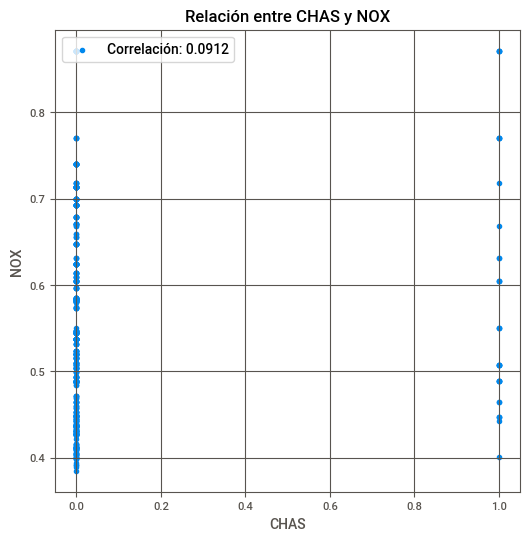

In [ ]:
import matplotlib.pyplot as plt

variable_1 = "TAX"
variable_2 = "MEDV"
#variable_1 = "LSTAT"
#variable_2 = "CRIM"
# en clase, mostrar también este ejemplo
#variable_1 = "CHAS"
#variable_2 = "NOX"

# creamos el scatter plot
plt.figure(figsize=(6, 6))  # con esta línea podemos ajustar el tamaño de la gráfica
plt.scatter(raw_dataset[variable_1], raw_dataset[variable_2])
plt.xlabel(variable_1)
plt.ylabel(variable_2)
plt.title("Relación entre {} y {}".format(variable_1, variable_2))

# calcular la correlación de Pearson usando SciPy
coeficiente_correlacion, _ = stats.pearsonr(raw_dataset[variable_1], raw_dataset[variable_2])
# agregar la leyenda con el valor del coeficiente de correlación
plt.legend([f"Correlación: {coeficiente_correlacion:.4f}"], loc="upper left")

# Mostrar el gráfico
plt.grid(True)
plt.show()


Vamos a ver muchas gráficas en las próximas clases, así que no nos vamos a detener mucho en esta. Simplemente usemos el sentido común para interpretarla: vemos que en los valores de INDUS bajos hay una dispersión de los valores de NOX (lo que podría sugerir que, en lugares donde no hay un gran número de establecimientos comerciales no minoristas, el grado de contaminación varía, porque puede estar explicado por otras variables), mientras que para valores más altos, hay una tendencia a que NOX también crezca (excepto esa pequeña banda en donde varias muestras con un mismo valor de INDUS muestras variaciones de NOX).

Analizar estas gráficas es importante, porque puede ocurrir que veamos una correlación baja y que en realidad exista una relación entre dos variables, solo que no lineal, como en estos ejemplos:

![](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/600px-Correlation_examples2.svg.png)

### 1.2 - Matriz de correlación

Estudiar las correlaciones una a una puede ser engorroso, sobre todo si trabajamos con muchísimas variables.

Una manera de resumir todas las posibles relaciones es construyendo una matriz de correlación, donde presentemos todos los valores de correlación entre todos los posibles pares de variables.

Olvídense de tener que hacer eso iterando con un doble for. Podemos hacerlo directamente en Pandas, usando el método ```corr()```. El método calcula un tipo de correlación que nosotros le digamos según el parámetro ```method``` (que es opcional y por defecto está seteada en Pearson, pero también podría ser [Kendall](https://es.wikipedia.org/wiki/Coeficiente_de_correlaci%C3%B3n_de_rango_de_Kendall) o [Spearman](https://es.wikipedia.org/wiki/Coeficiente_de_correlaci%C3%B3n_de_Spearman) o incluso una función que nosotros programemos), ignorando en todos los casos si hay un valor faltante.

Veamos cómo nos queda la matriz de correlación para nuestra base de datos:

In [ ]:
# calculamos las correlaciones entre features e imprimimos la matriz
correlation_matrix = raw_dataset.corr()
correlation_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


En esta matriz tenemos un resumen completo del comportamiento bivariado de todas las variables del conjunto, según el coeficiente de correlación.

Habrán notado que la matriz tiene todos 1 en la diagonal (porque efectivamente una variable tiene un coeficiente de correlación lineal de 1 consigo misma), pero que además es simétrica respecto a esa diagonal (porque la correlación entre A y B es la misma que entre B y A).

Si quisiéramos por ejemplo identificar más fácilmente los casos de correlaciones elevadas o bajas, podríamos representar esta matriz gráficamente, asignando colores a cada uno de los valores. Podríamos, por ejemplo, usar un color neutro para los valores cercanos a cero, y transicionar hacia valores más fuertes cuando nos aproximamos a -1 o 1.

Esto es lo que se conoce como "mapa de calor", o heatmap en inglés. La librería Seaborn (una que vamos a usar para la gran mayoría de nuestras visualizaciones, montaba sobre otra también muy útil, Matplotlib) lo incluye con el nombre ```heatmap``` y es bastante fácil de usar, solamente nos pide que pasemos la matriz, un valor mínimo ```vmin```, un máximo ```vmax``` y el valor central ```center```, y a partir de un mapa de colores ```cmap``` nos representará la matriz, incluyendo anotaciones si le passamos ```anot``` en ```True```:

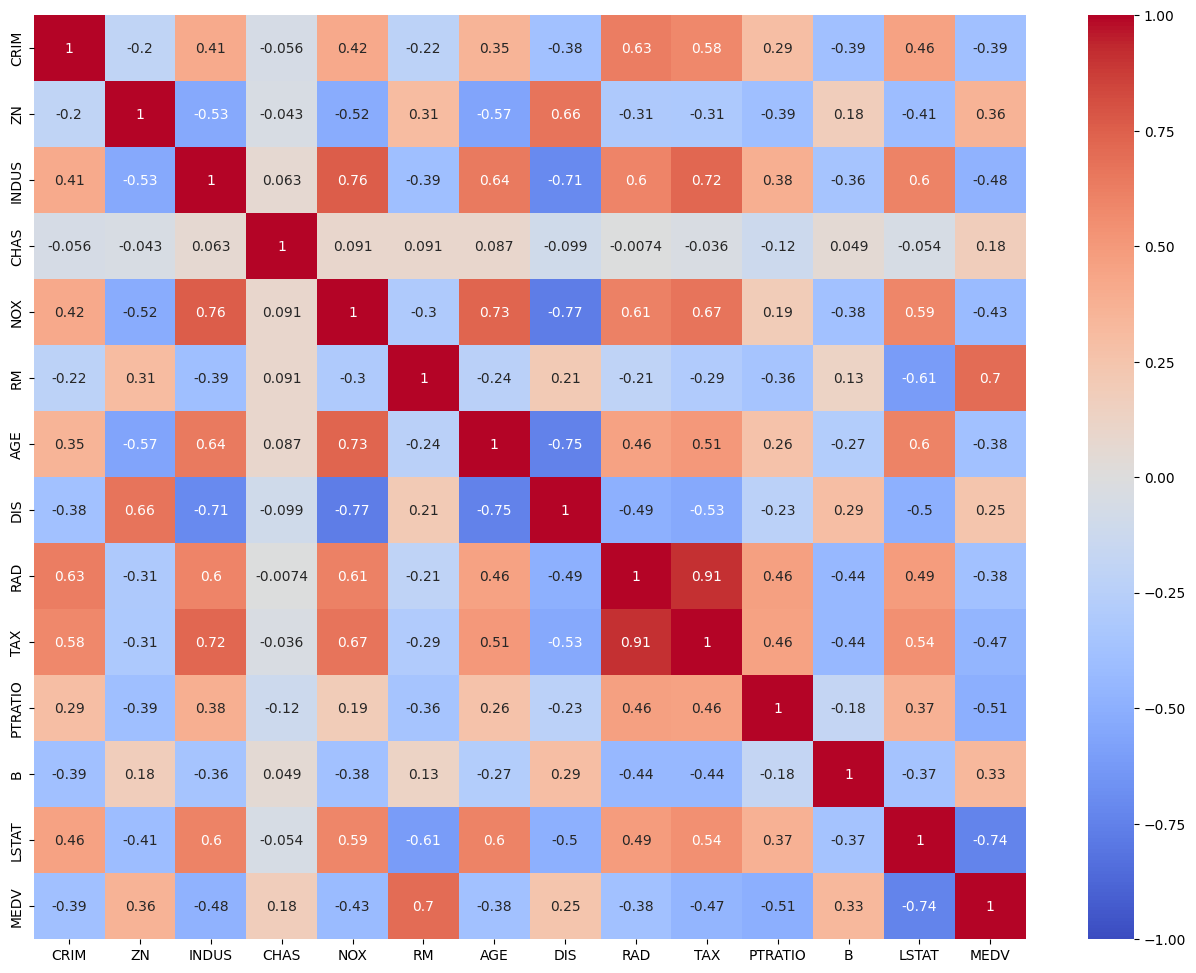

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

Si quisiéramos aplicar la *rule of thumb* se considerar altas a las correlaciones cuyo valor absoluto sea mayor a 0.7, podríamos hacerlo fácilmente umbralizando la matriz en ese valor. Aprovechemos también y removamos los valores de la diagonal, para no generar confusiones:

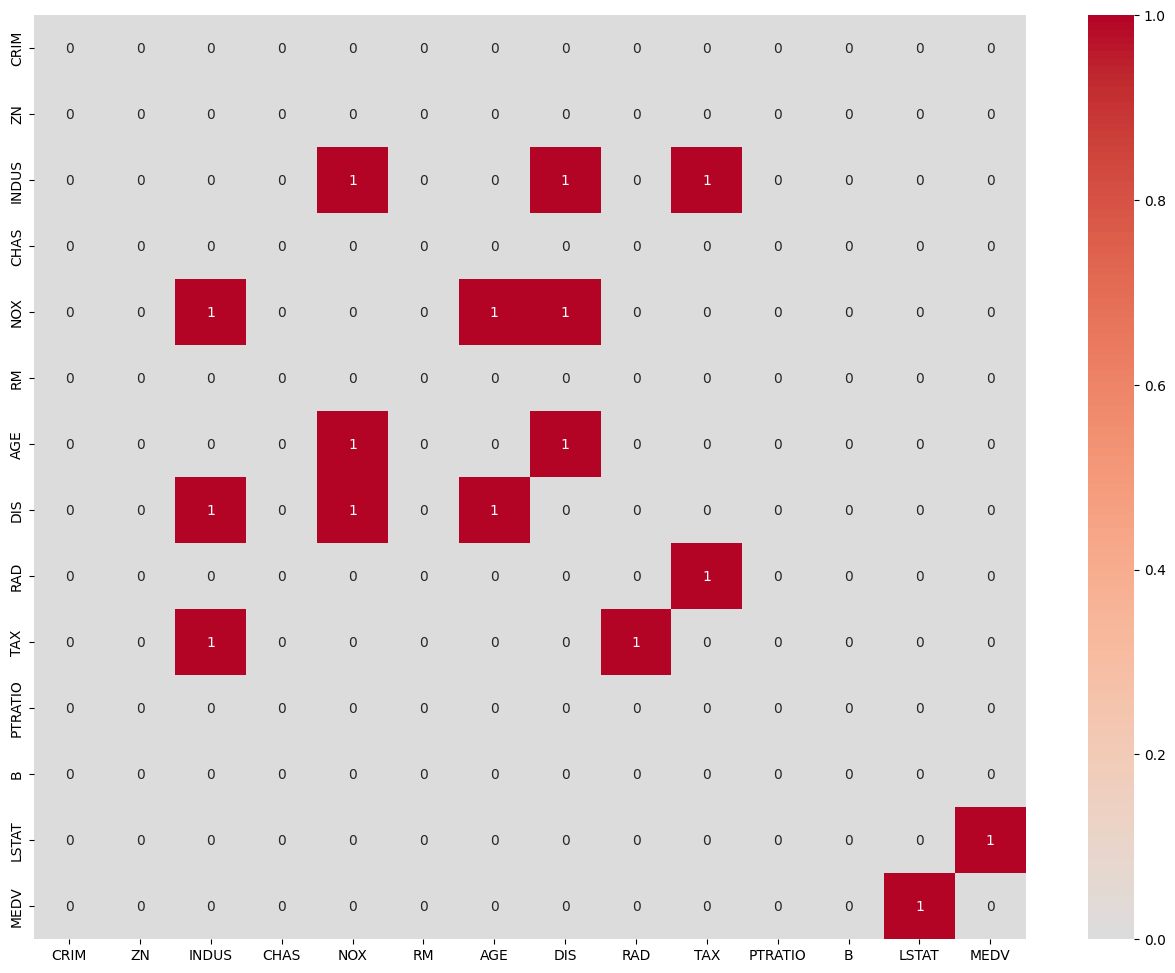

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# tomamos el valor absoluto de las correlaciones, umbralamos las mayores a 0.7
correlation_matrix_umbralizada = correlation_matrix.abs() > 0.7
# aprovechamos y sacamos la diagonal
np.fill_diagonal(correlation_matrix_umbralizada.values, 0)

# e imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12));
sns.heatmap(correlation_matrix_umbralizada, vmin=0.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

Como en el [juego de la batalla naval](https://es.wikipedia.org/wiki/Batalla_naval_(juego)) (espero que lo conozcan), nos quedan indicadas las relaciones con correlaciones absolutas mayores a 0.7, para que, por ejemplo, las analicemos una a una, utilizando un scatter plot:

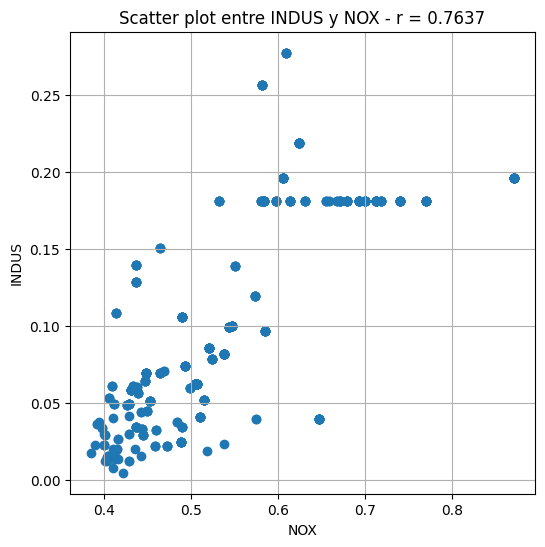

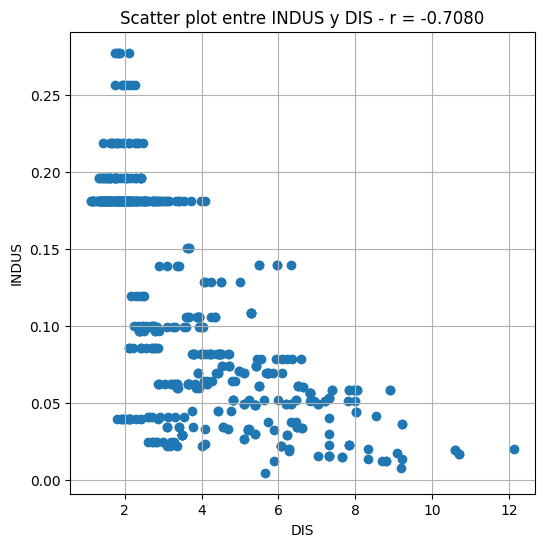

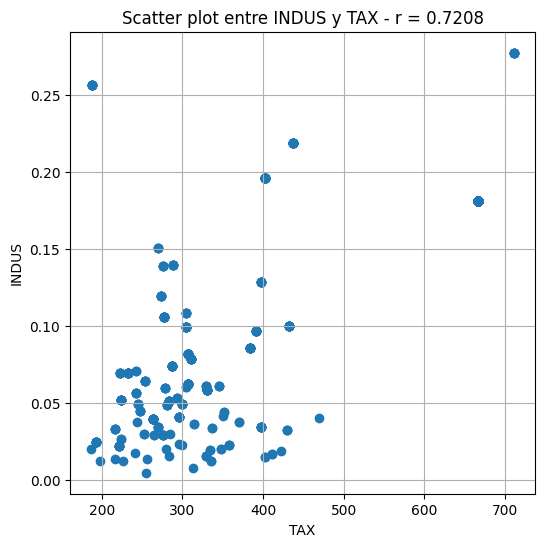

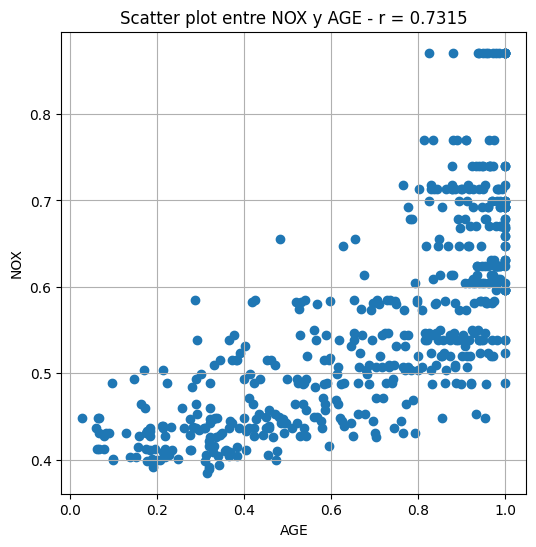

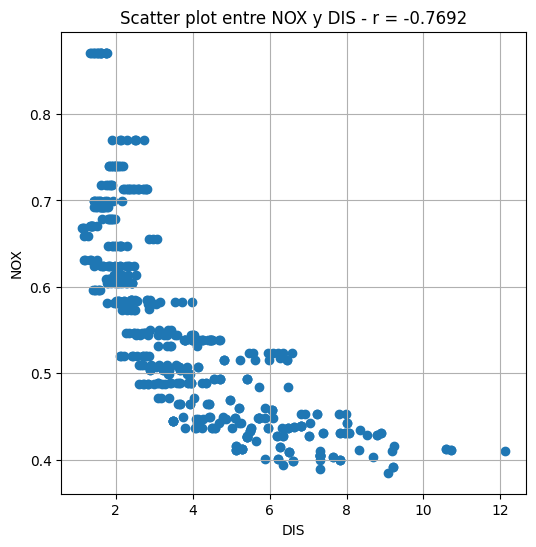

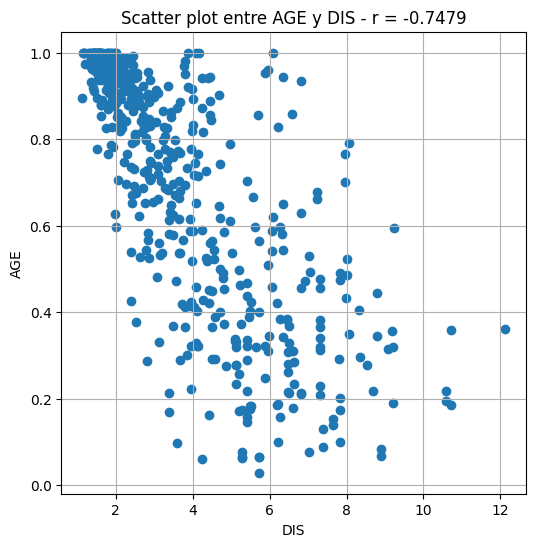

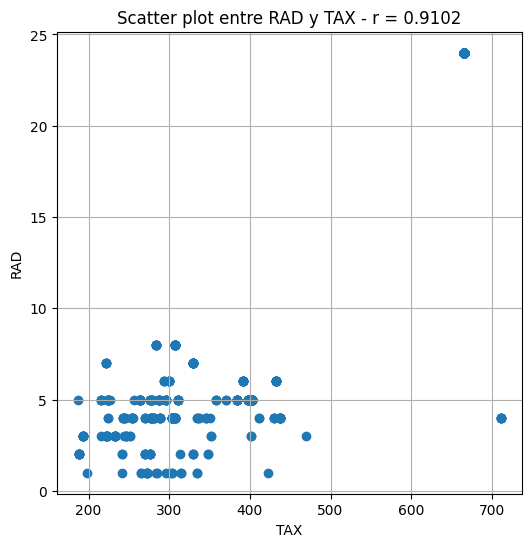

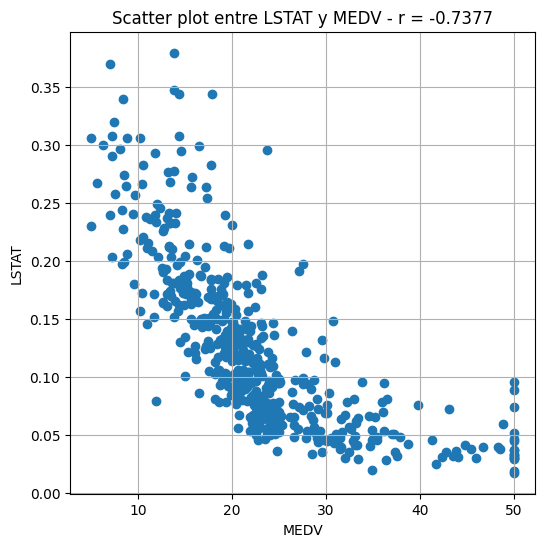

In [ ]:
# iteramos por cada una de las columnas
for i, col in enumerate(correlation_matrix_umbralizada.columns):
  # y por cada una de las filas (para eso usamos el índice)
  for j in range(i,len(correlation_matrix_umbralizada.index)):
    # extraemos el nombre de la fila en la que estamos
    row = correlation_matrix_umbralizada.index[j]
    # si en esa posición tenemos un True en la matriz umbralizada
    if correlation_matrix_umbralizada.loc[row, col]:
      # nos traemos el valor de esa correlación
      correlation = correlation_matrix.loc[row, col]
      # representamos en un scatter plot cuadrado los valores de ambas variables
      plt.figure(figsize=(6, 6))
      plt.scatter(raw_dataset[row], raw_dataset[col])
      # y lo mostramos bonito
      plt.title(f"Scatter plot entre {col} y {row} - r = {correlation:.4f}")
      plt.xlabel(row)
      plt.ylabel(col)
      plt.grid(True)
      plt.show()

## 2 - Un atajo: Sweetviz

Sweetviz es una biblioteca de Python orientada al análisis exploratorio de datos (EDA) que permite generar, de manera automática, un reporte visual e interactivo sobre un conjunto de datos. A partir de un DataFrame, Sweetviz resume las principales características de cada variable y facilita la detección inicial de patrones, valores faltantes, distribuciones inusuales y posibles relaciones entre atributos.

El reporte generado incluye información como el tipo de cada variable, cantidad de valores distintos y faltantes, estadísticas descriptivas, distribuciones mediante gráficos y asociaciones entre variables. Esto permite obtener rápidamente una primera idea sobre la estructura y calidad de los datos antes de comenzar un análisis más detallado.

Una característica particularmente útil de Sweetviz es que puede analizar las variables en relación con una variable objetivo. Por ejemplo, en un problema de clasificación es posible indicar cuál es la clase que se desea predecir y observar cómo se distribuyen las demás variables para los distintos valores de esa clase. También permite comparar directamente dos conjuntos de datos, algo útil para estudiar diferencias entre subconjuntos de entrenamiento y prueba o entre diferentes grupos de observaciones.

Es importante tener en cuenta que Sweetviz funciona principalmente como una herramienta de exploración inicial. Los gráficos y asociaciones que presenta pueden sugerir patrones o posibles problemas en los datos, pero no reemplazan el análisis estadístico posterior ni permiten concluir por sí solos que exista una relación causal entre las variables.

Primero tenemos que instalar la librería:

In [ ]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 81.4 MB/s eta 0:00:00


Para generar un reporte básico sobre nuestro conjunto, podemos hacer esto:

                                             |          | [  0%]   00:00 -> (? left)


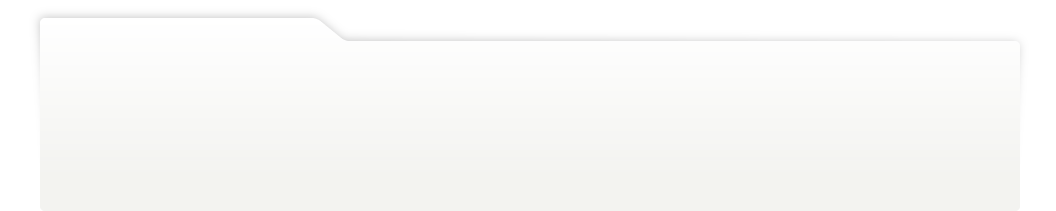
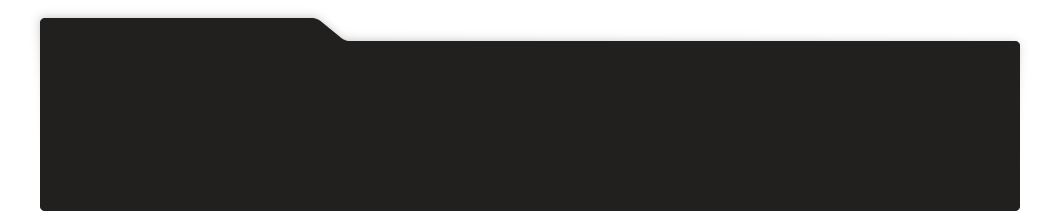
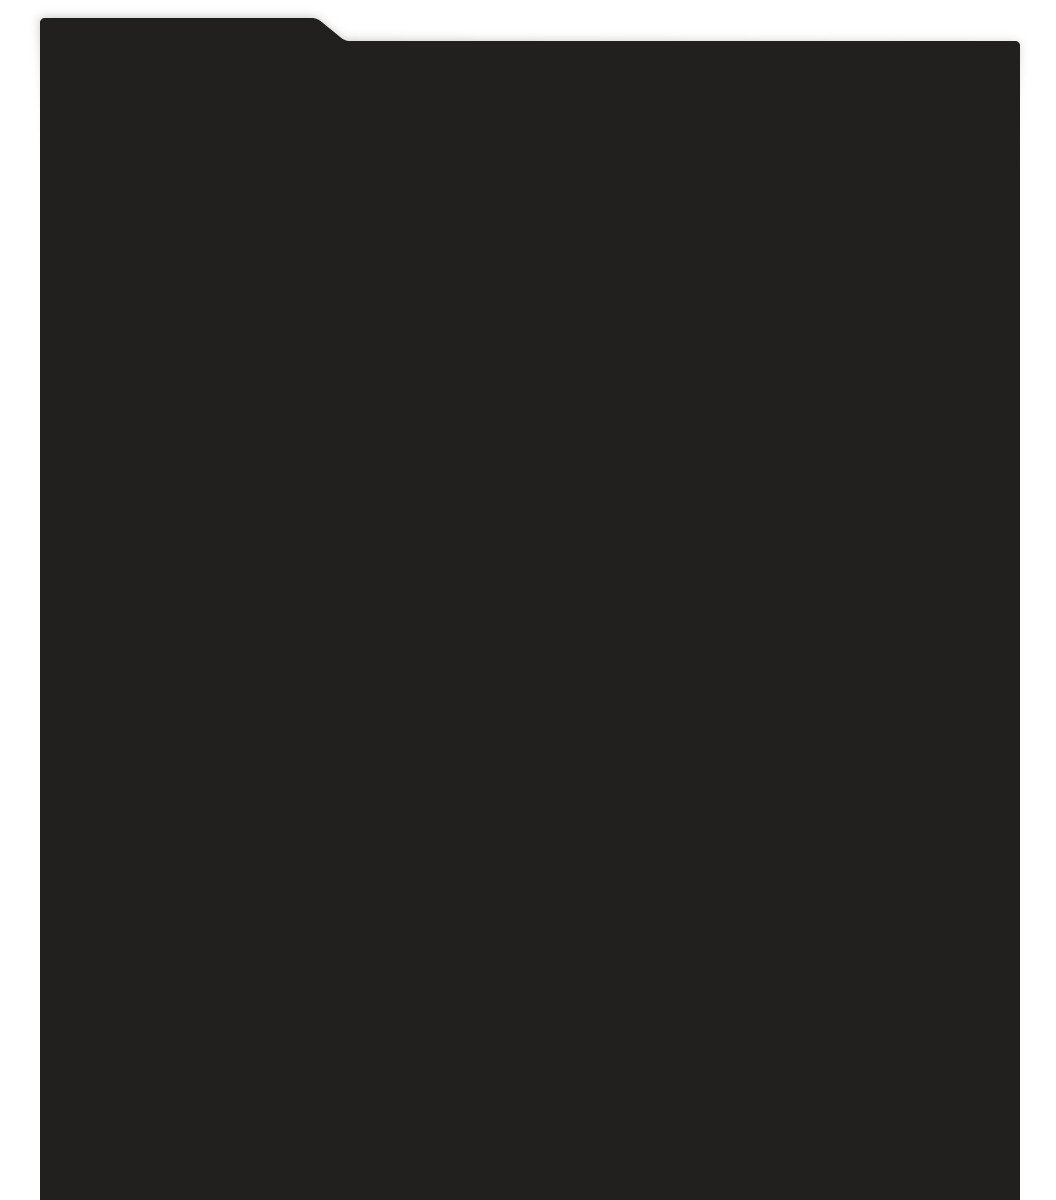
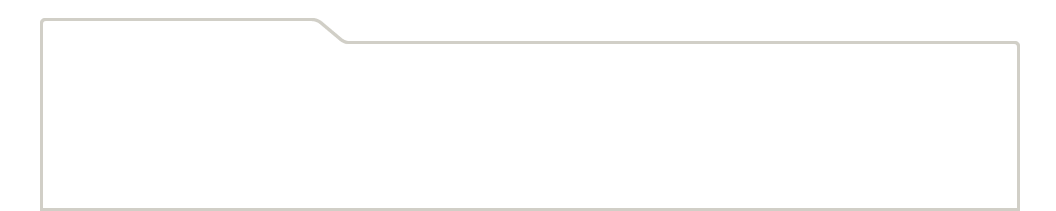
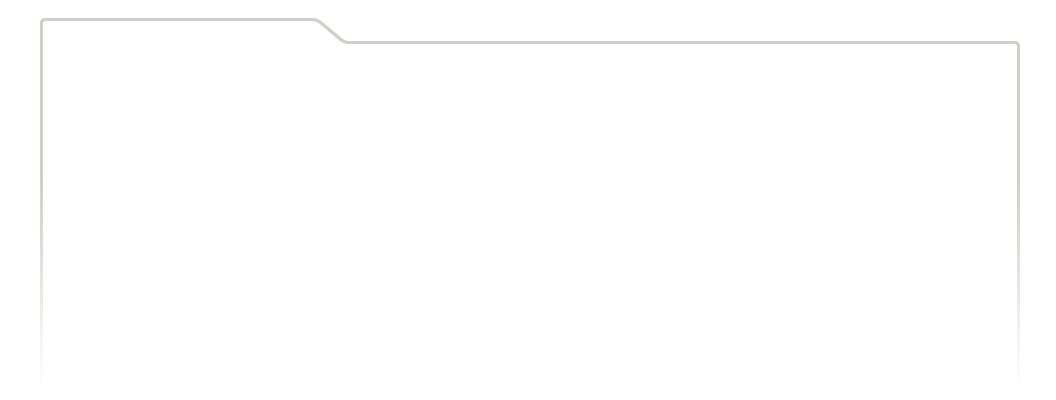
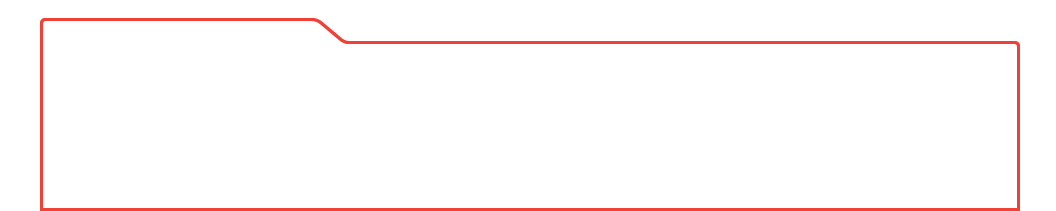
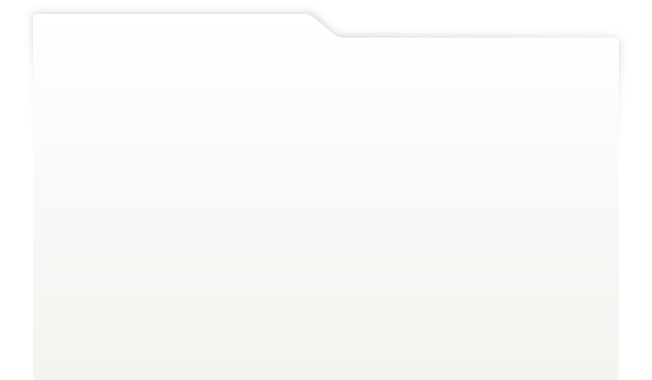
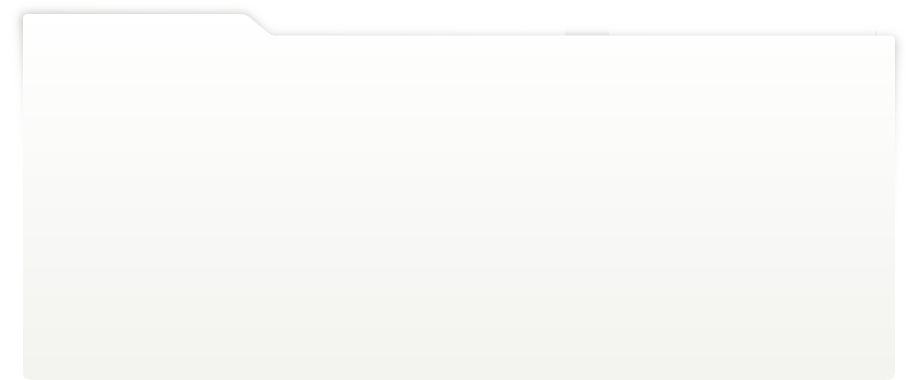
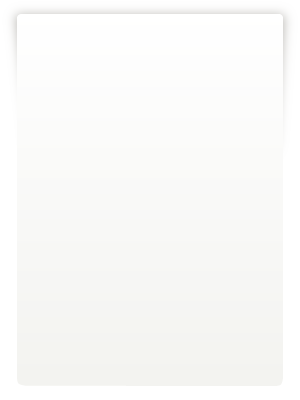
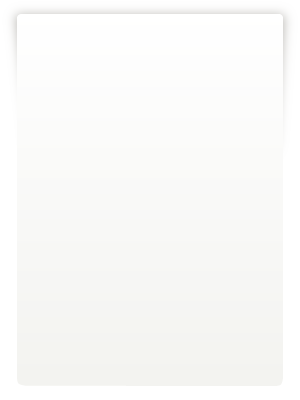
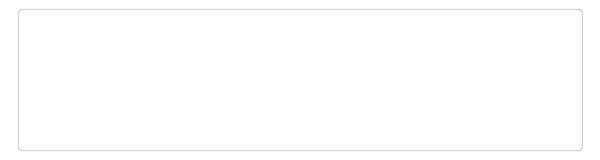
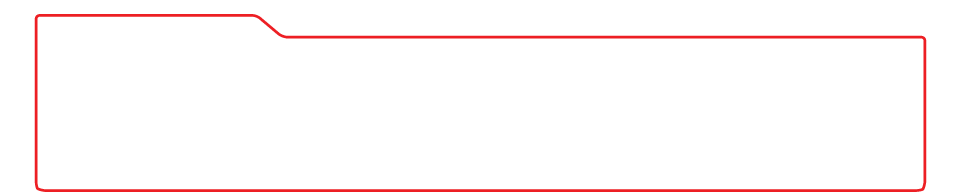
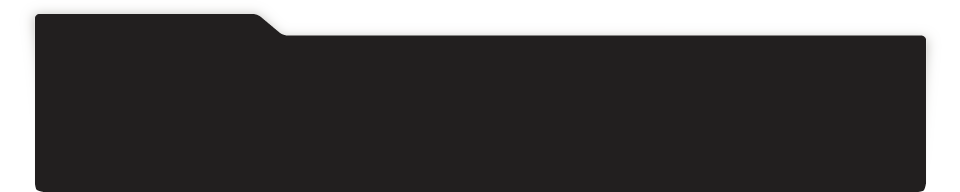
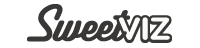
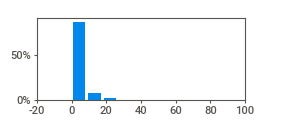
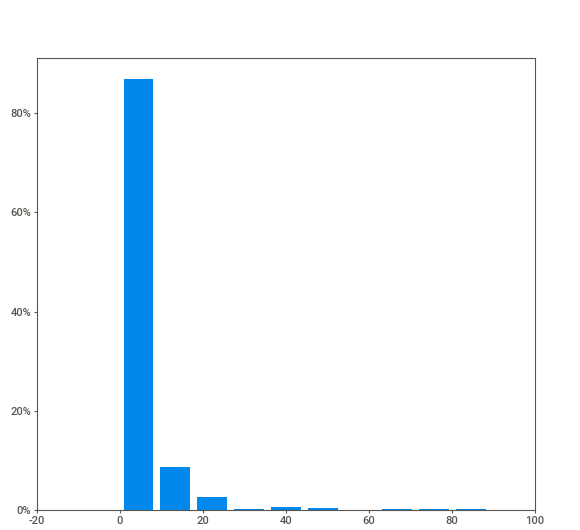
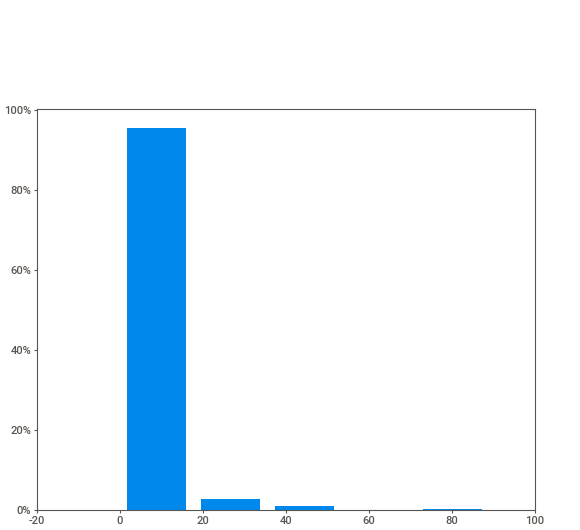
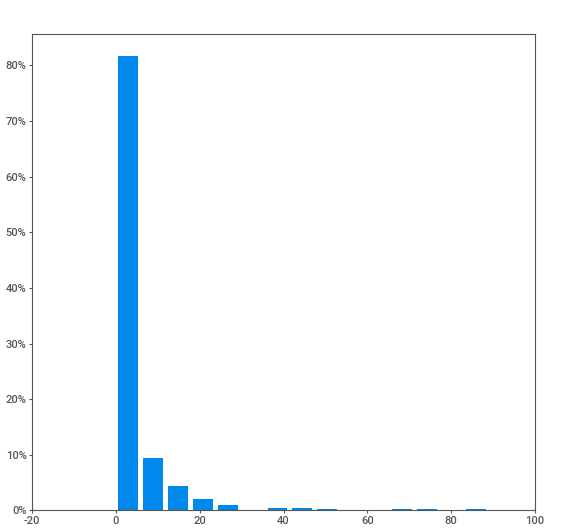
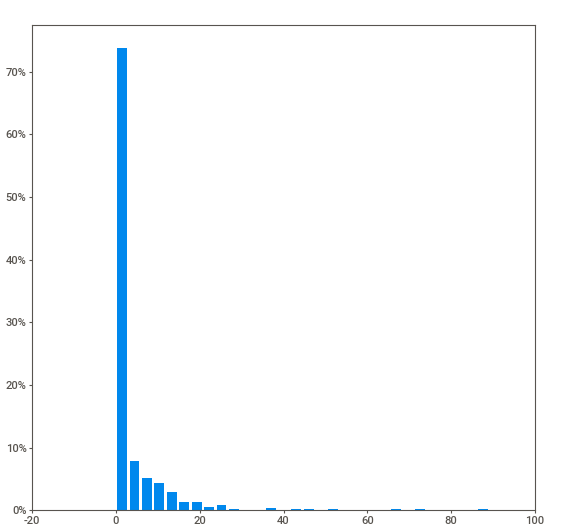
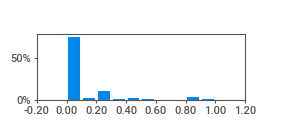
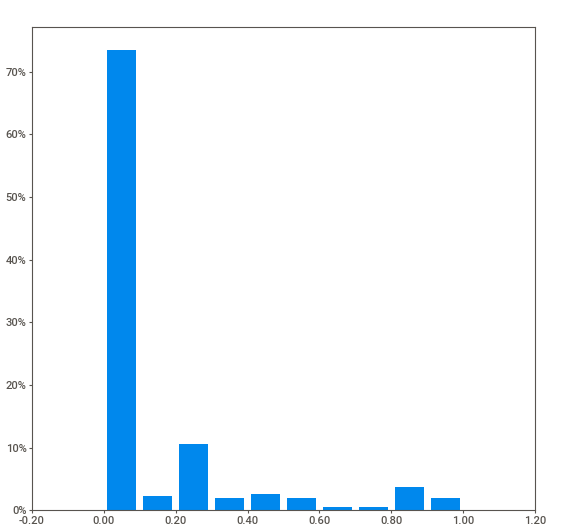
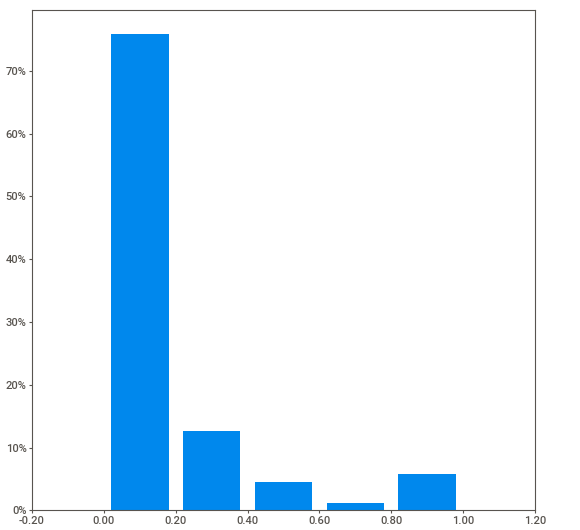
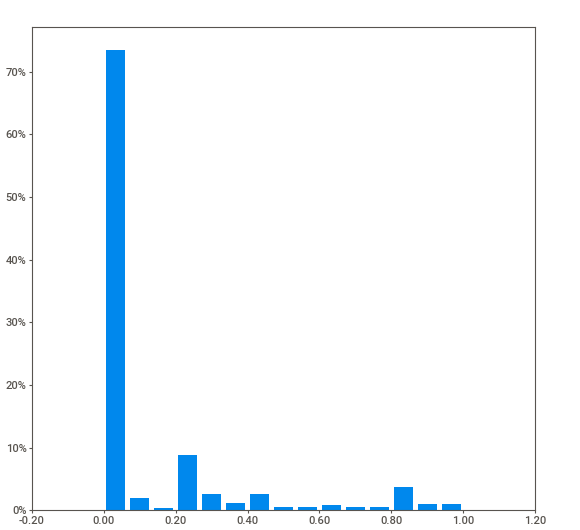
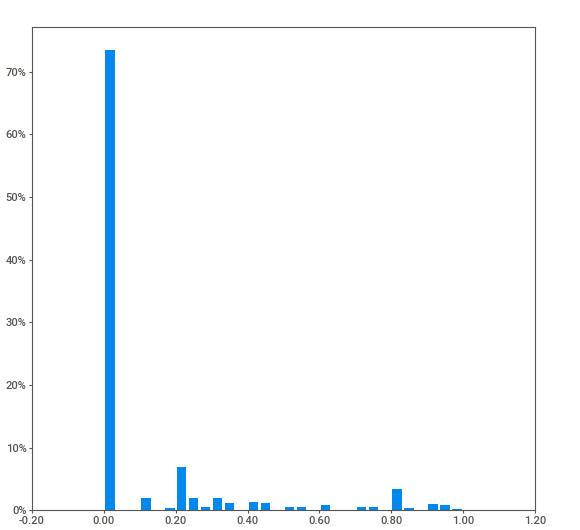
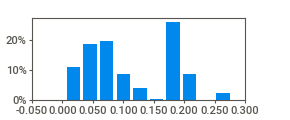
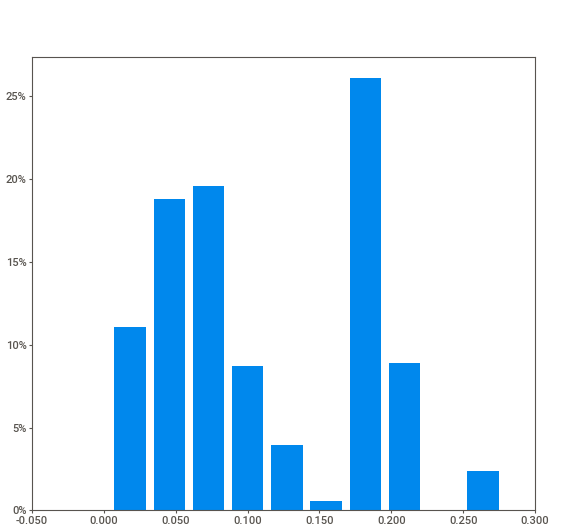
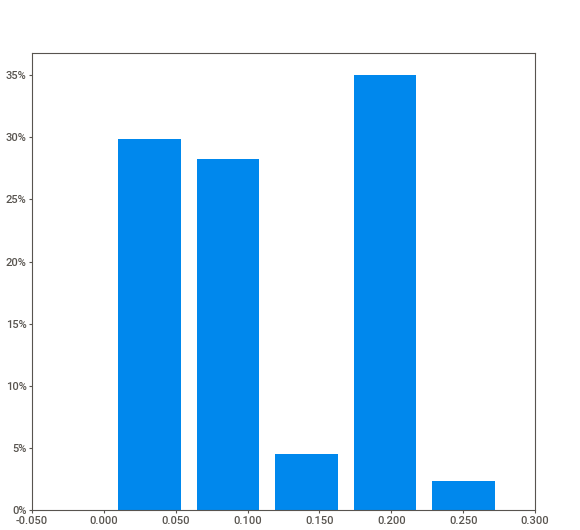
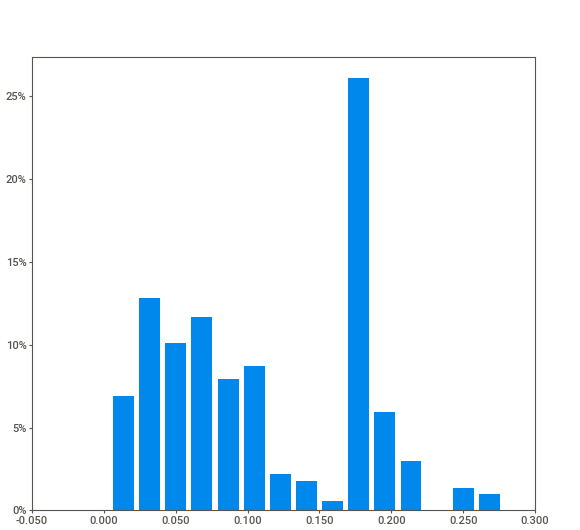
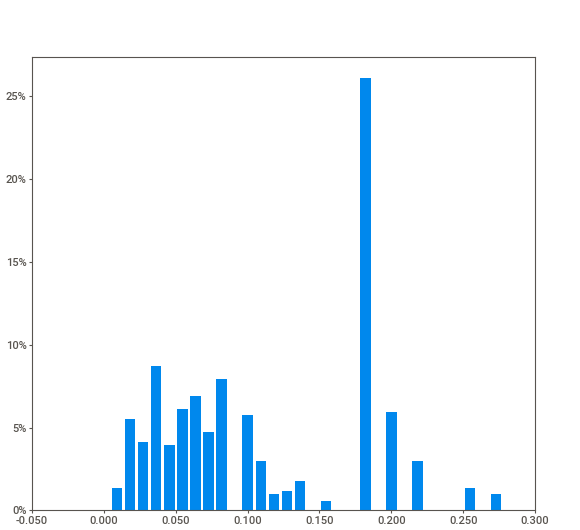
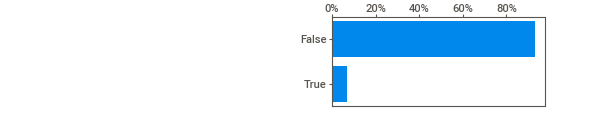
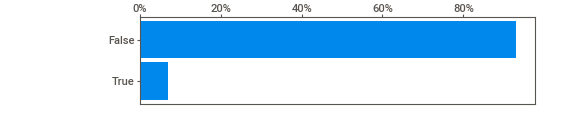
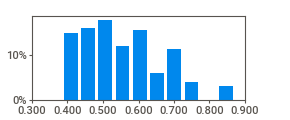
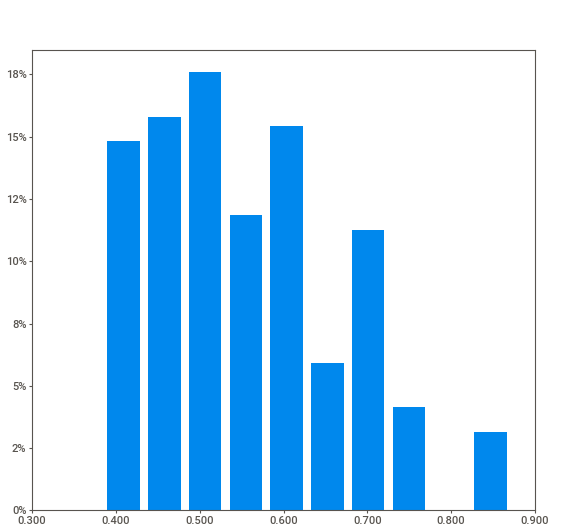
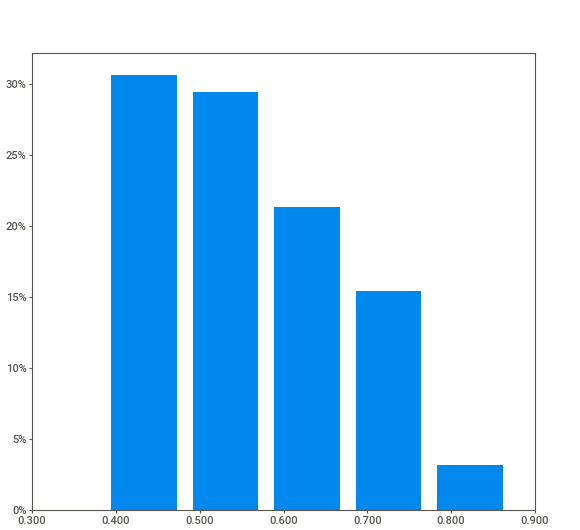
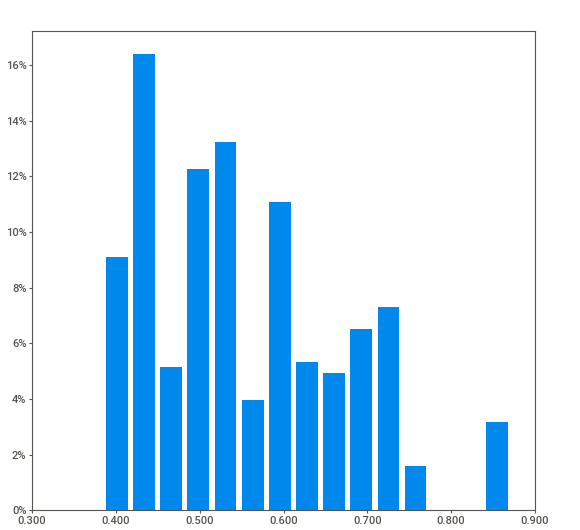
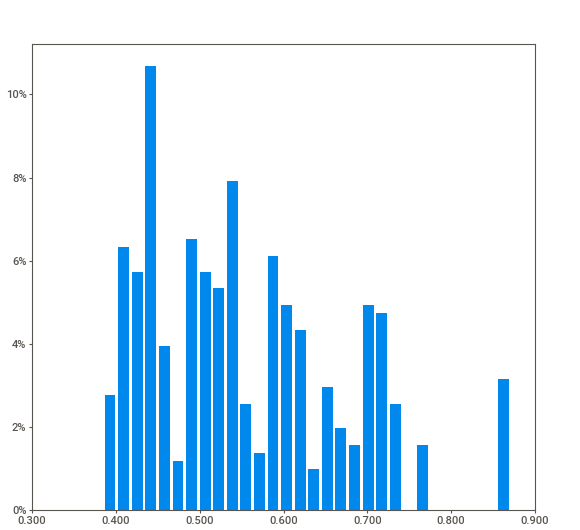
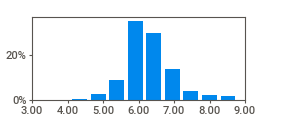
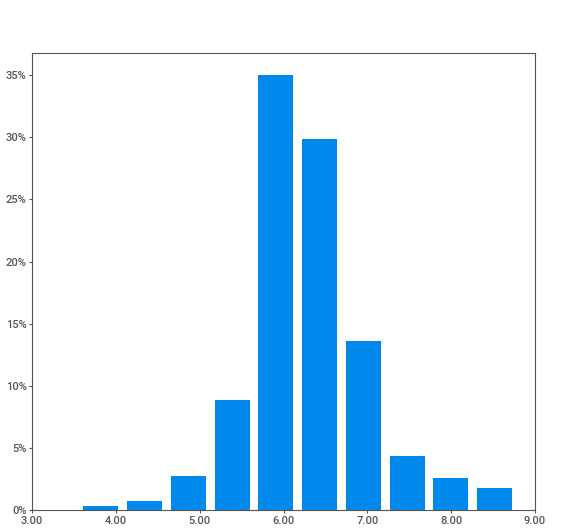
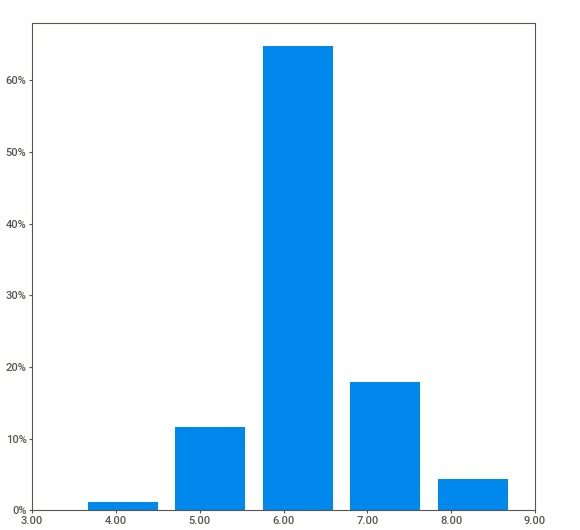
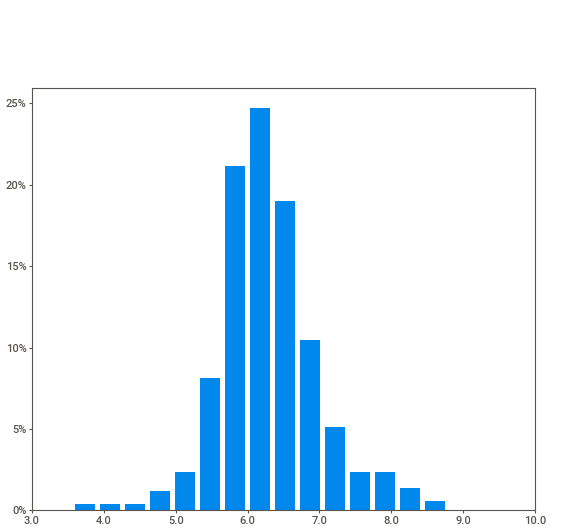
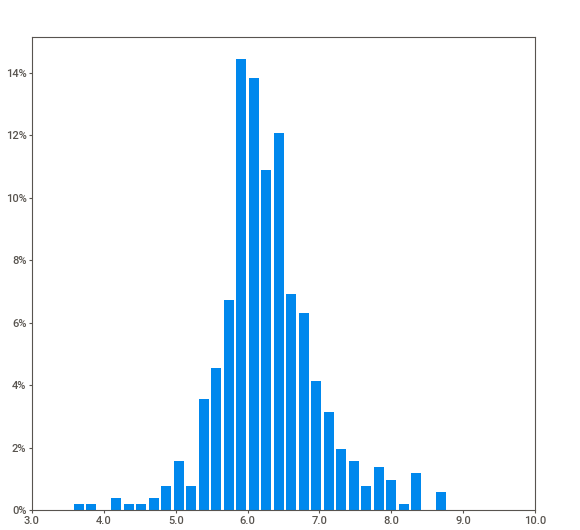
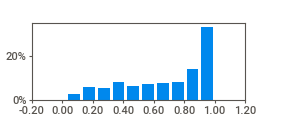
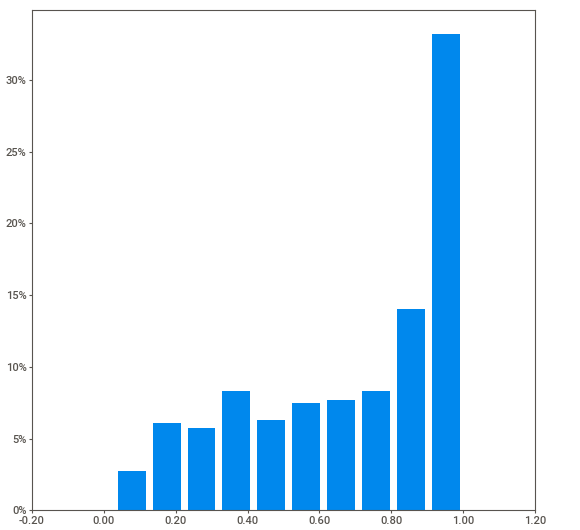
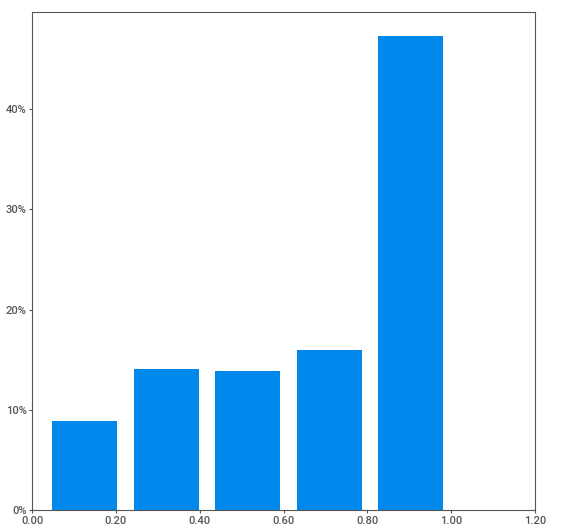
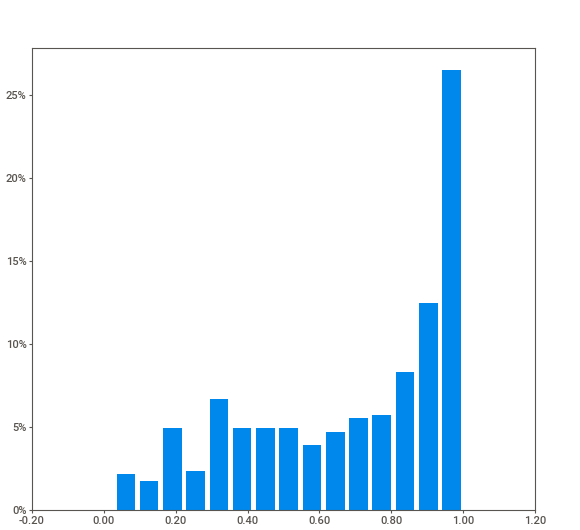
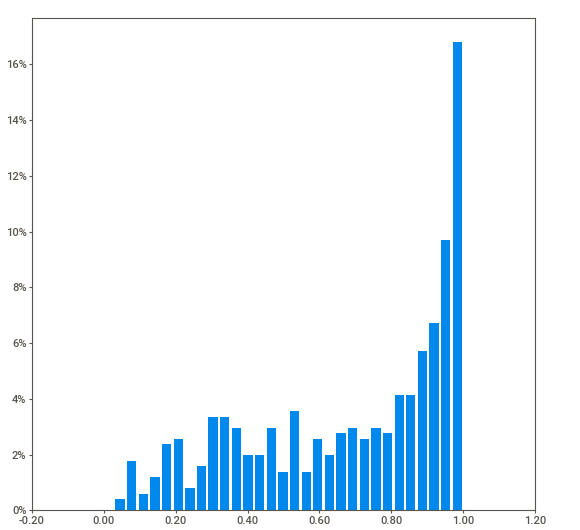
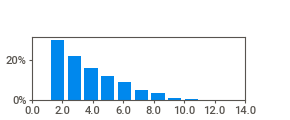
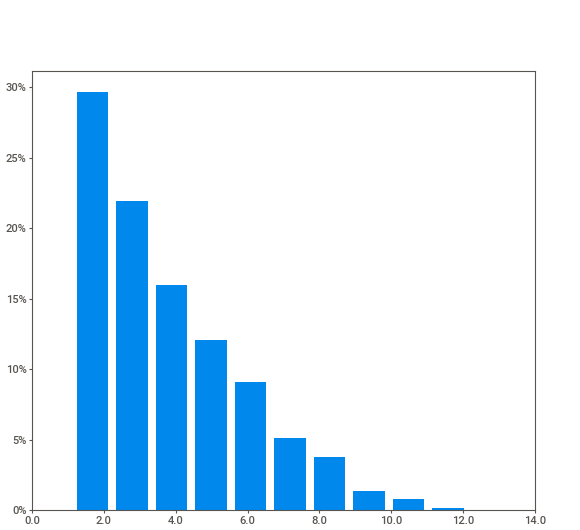
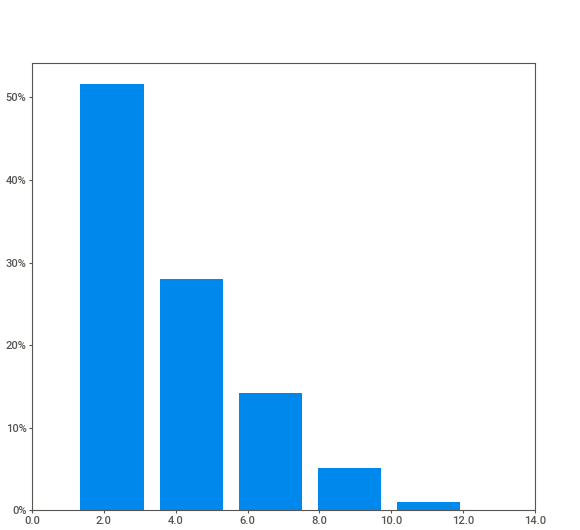
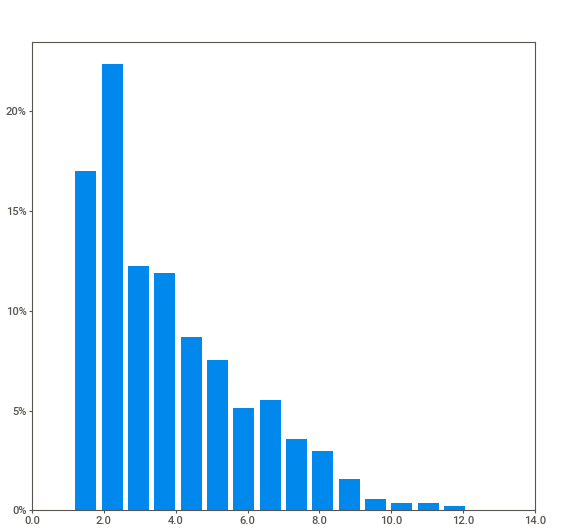
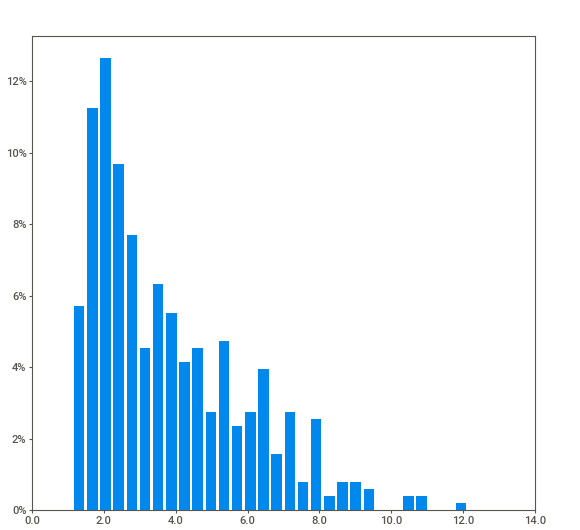
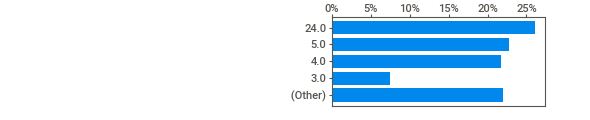
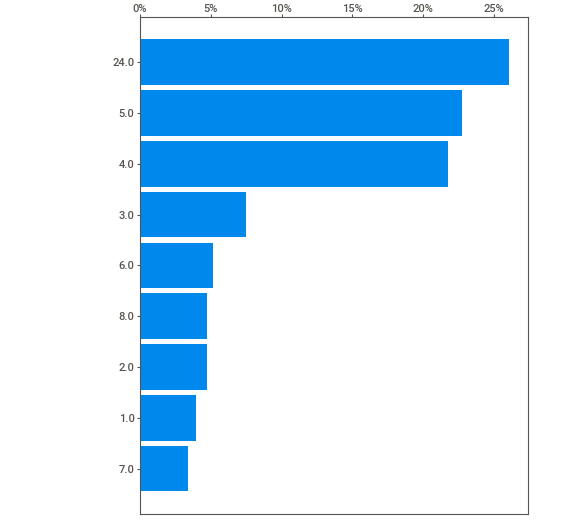
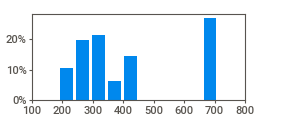
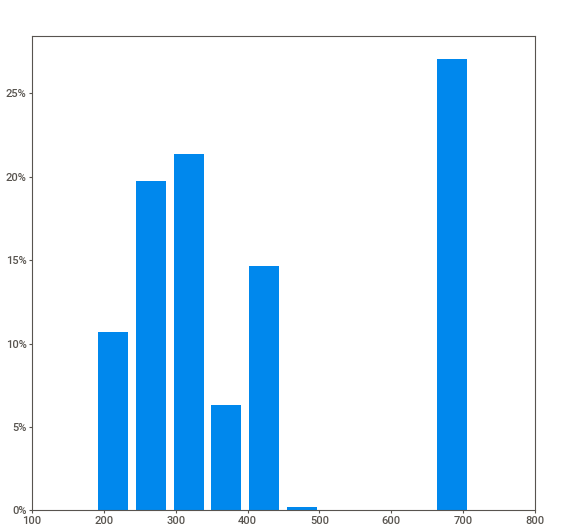
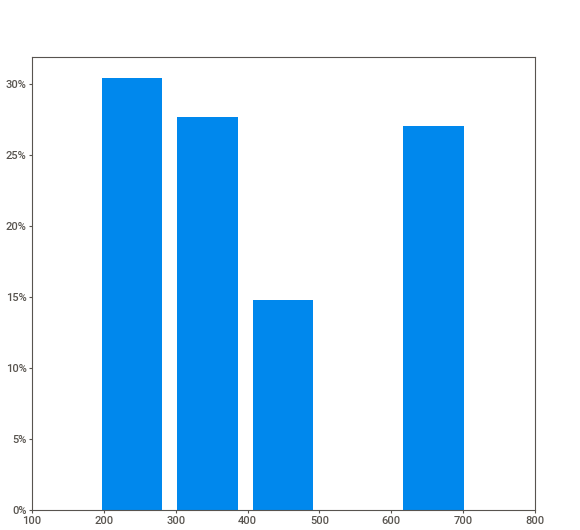
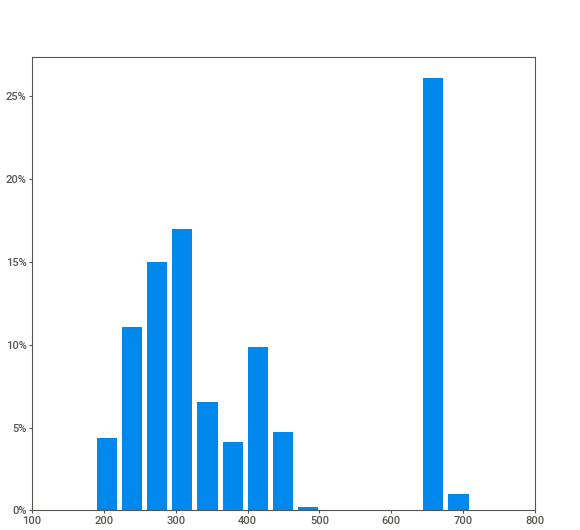
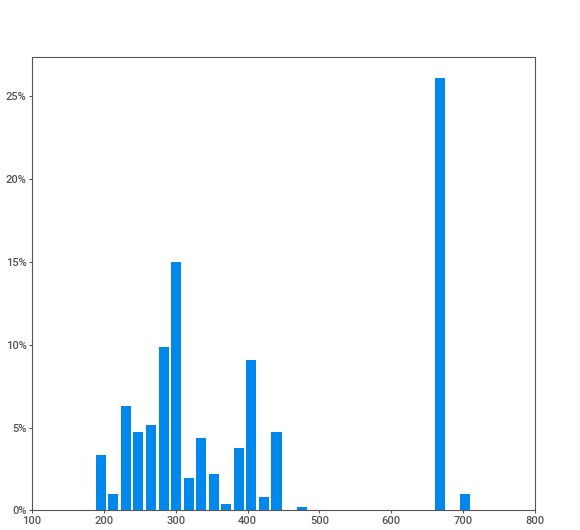
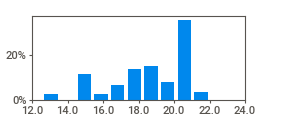
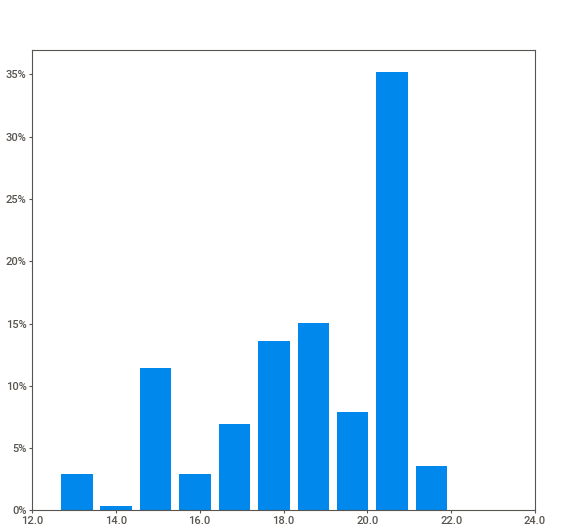
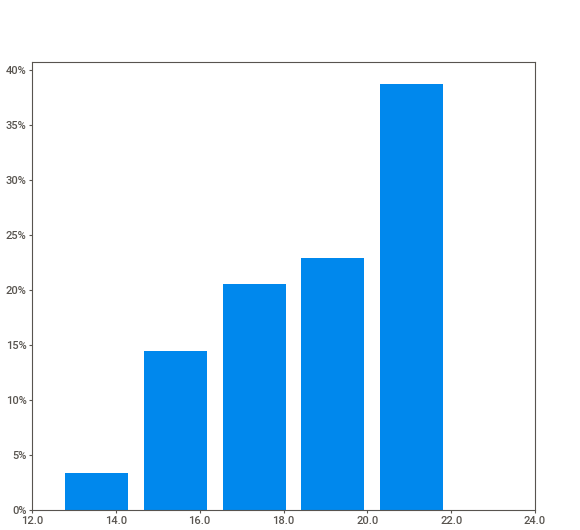
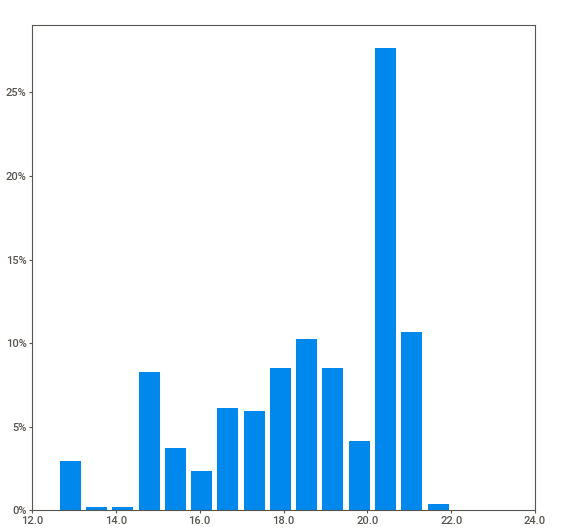
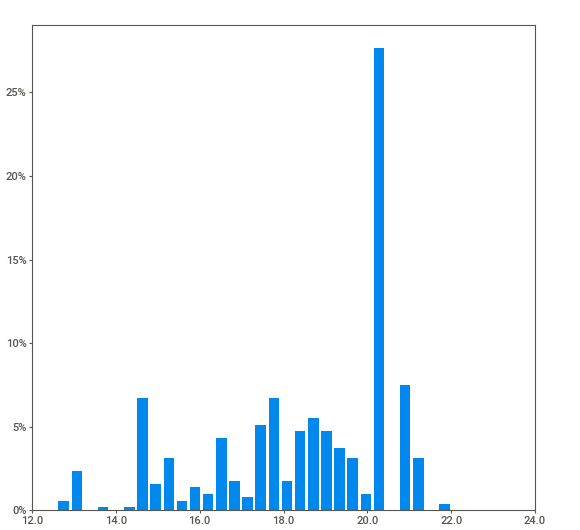
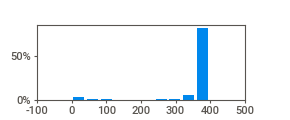
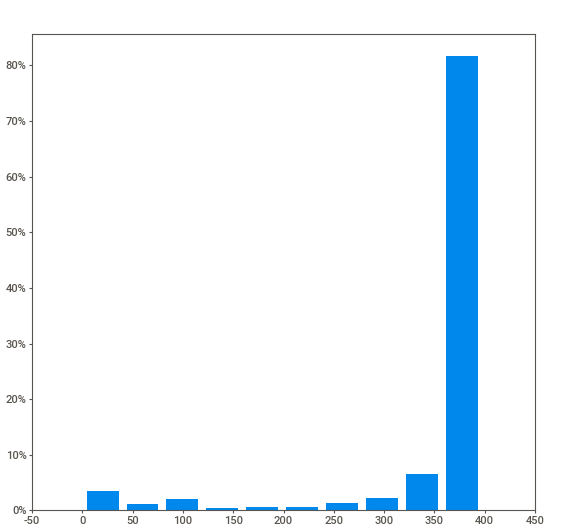
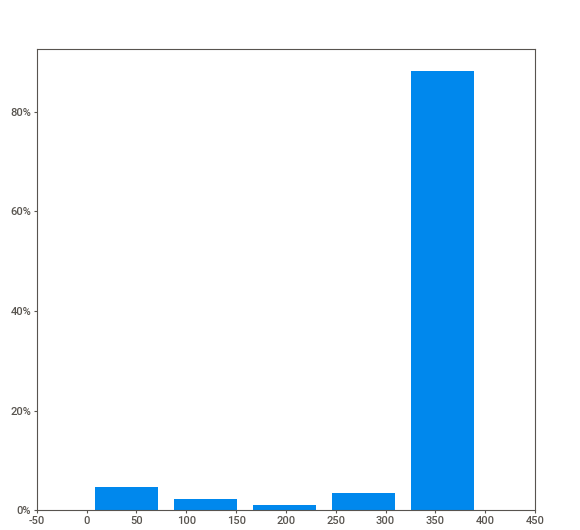
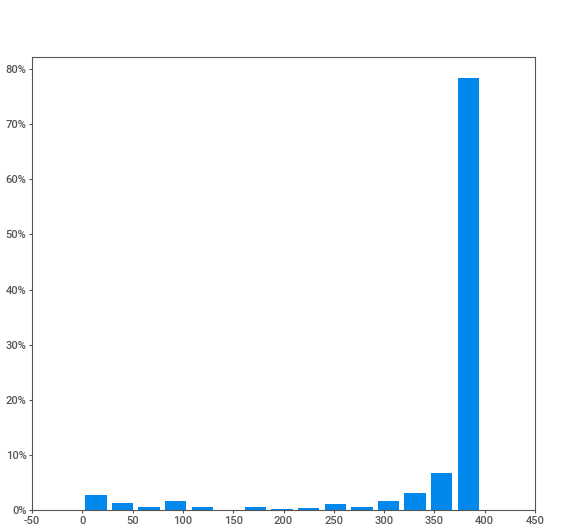
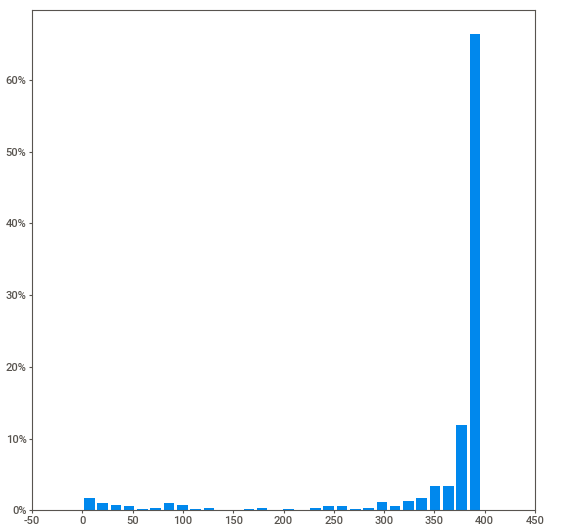
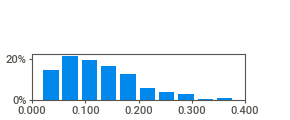
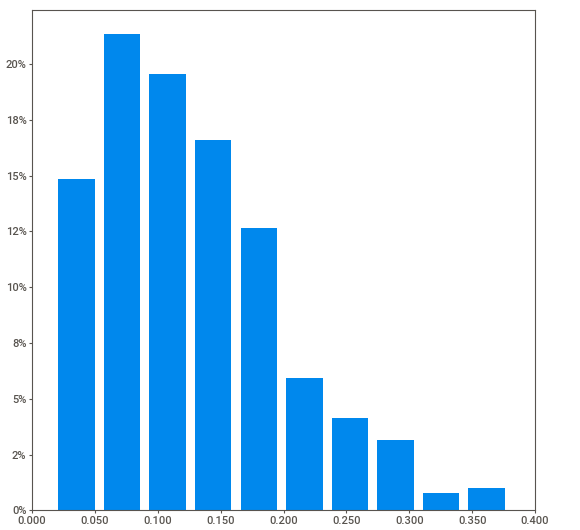
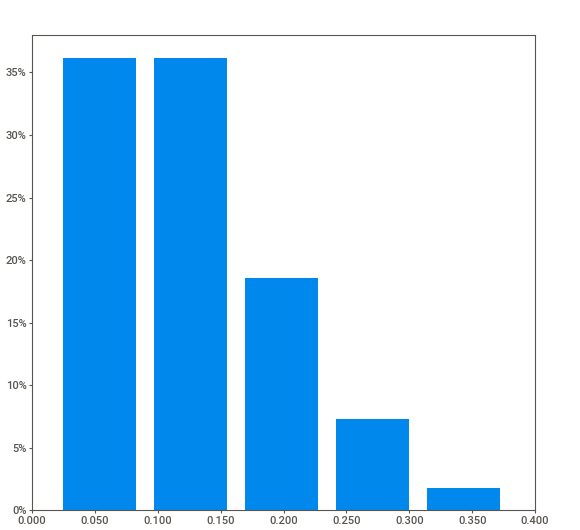
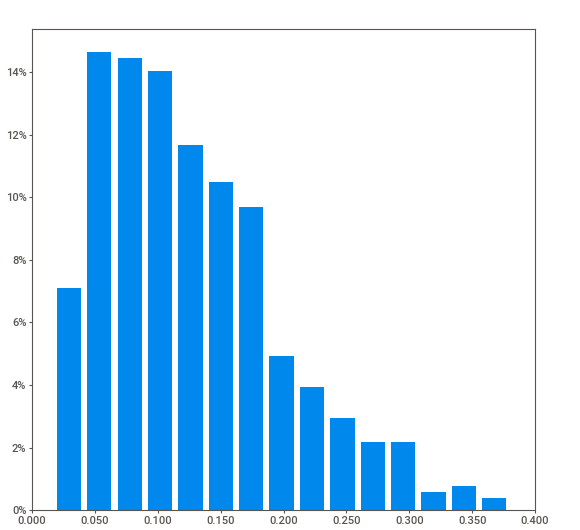
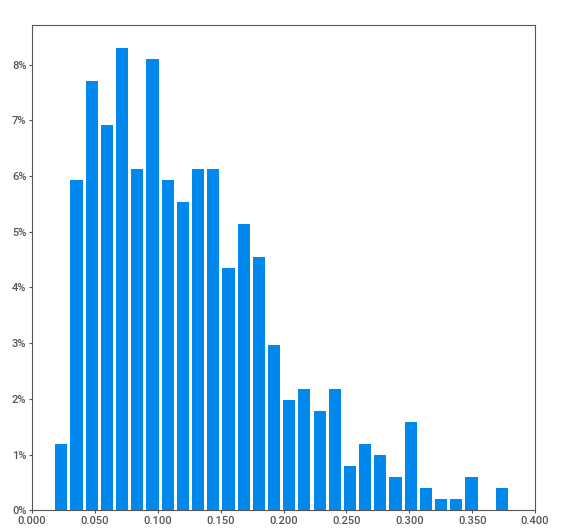
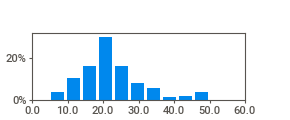
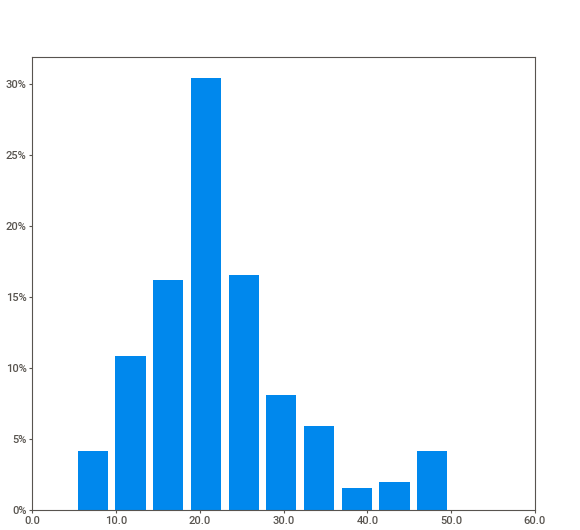
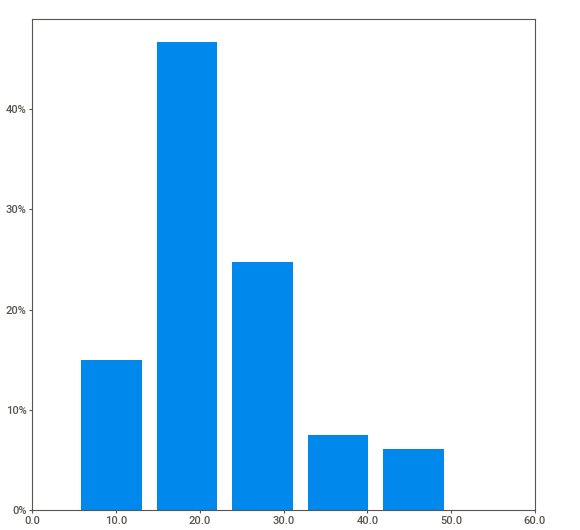
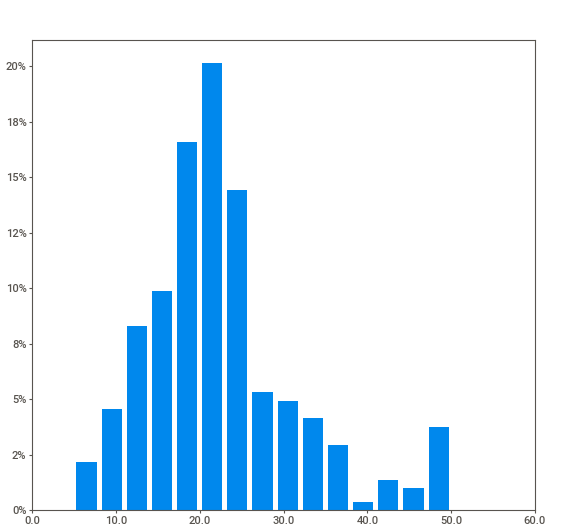
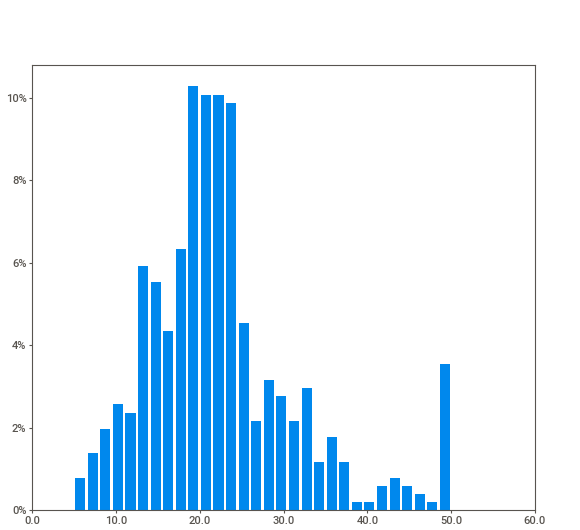
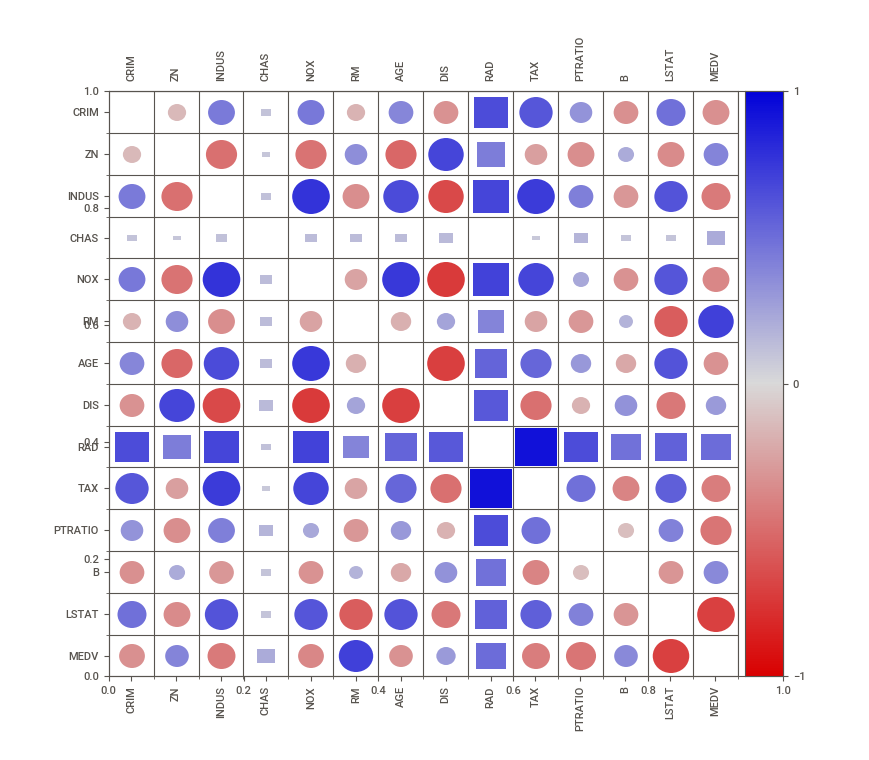
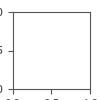

In [ ]:
import sweetviz as sv

reporte = sv.analyze(raw_dataset)
reporte.show_notebook()

A partir de este reporte podemos comenzar a formular preguntas sobre los datos, identificar variables que requieran algún tipo de preprocesamiento y decidir qué análisis conviene realizar a continuación.

Y esto es todo por hoy! Con todo lo que vimos hoy y la clase pasada, ya pueden terminar el Práctico 2 y el Práctico 3 de la materia. Recuerden que lo ideal para ambos prácticos es que los trabajen en grupo, para enriquecer un poco más sus análisis y sacar conclusiones más copadas!